<a href="https://colab.research.google.com/github/sevval-345/NLP/blob/main/tf_idf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF: Kelimelerin Önemini Sayısal Olarak Ölçmek
 
Bu notebook, metin verisini makine öğrenmesi modellerinin anlayabileceği sayısal vektörlere çevirmenin en klasik ve en çok kullanılan yöntemlerinden biri olan **TF-IDF (Term Frequency – Inverse Document Frequency)**'i baştan sona işler.
 
## Neden bir "sayısallaştırma" yöntemine ihtiyacımız var?
 
Bilgisayarlar metni doğrudan anlayamaz; sadece sayılarla işlem yapabilir. Bu yüzden bir cümleyi veya dokümanı bir makine öğrenmesi modeline (örneğin bir sınıflandırıcıya) verebilmek için önce onu bir **vektöre** (sayı dizisine) dönüştürmemiz gerekir. Buna metinlerde **vektörleştirme (vectorization)** denir.
 
En basit yaklaşım **Bag-of-Words (Kelime Çantası)**'dır: her doküman için, kelime dağarcığındaki (vocabulary) her kelimenin o dokümanda kaç kez geçtiğini sayarız. Ancak bu yaklaşımın büyük bir zayıflığı vardır: **"ve", "bir", "bu"** gibi hemen her dokümanda sık geçen ama hiçbir ayırt edici bilgi taşımayan kelimeler, gerçekten önemli olan **"deprem", "yapay zeka", "bütçe"** gibi kelimelerle aynı muameleyi görür, hatta sayıca onları gölgede bırakabilir.
 
**TF-IDF tam olarak bu sorunu çözmek için tasarlanmıştır.** Fikir şu: bir kelime,
- **bir dokümanda sık geçiyorsa** (yüksek TF) → o doküman için önemli olabilir,
- ama **tüm dokümanlarda da sık geçiyorsa** (yüksek DF, düşük IDF) → aslında pek ayırt edici değildir (örn. "ve", "bir").
 
TF-IDF, bu iki bilgiyi çarparak "bu kelime, bu doküman için ne kadar **karakteristik**?" sorusuna bir sayısal cevap üretir.
 
Notebook'un akışı şu şekilde olacak:
1. Tokenization (kelimelere ayırma)
2. TF-IDF'i **sıfırdan (manuel)** formülleriyle hesaplama
3. Aynı işi **scikit-learn** ile yapma ve farkları anlama
4. Sonuçları görselleştirme
5. TF-IDF'in **sınırlılıklarını** somut örneklerle keşfetme (anlam, bağlam, seyreklik, boyut laneti)
6. Alternatif/tamamlayıcı yöntemlere kısa bir bakış (yoğun vektörler / embedding'ler)


 1. Örnek Doküman Kümesi ve Tokenization
 
Aşağıdaki hücrede 5 kısa Türkçe cümleden oluşan küçük bir "korpus" (doküman kümesi) tanımlanıyor. Bu cümleler bilinçli olarak 3 farklı konuyu (yapay zekâ, uzay/teknoloji, sağlık) temsil edecek şekilde seçilmiş — böylece TF-IDF'in konulara özgü kelimeleri nasıl öne çıkardığını daha net görebileceğiz.
 
**Tokenization (belirteçleme)** nedir? Bir metni, üzerinde işlem yapılabilecek en küçük parçalara (genelde kelimelere) bölme işlemidir. Burada kullanılan `tokenize` fonksiyonu çok basit tutulmuş:
 
```python
def tokenize(text):
    return text.lower().split()
```
 
- `text.lower()` → tüm harfleri küçük harfe çevirir. Bu önemlidir çünkü aksi halde "Yapay" ve "yapay" model için **iki farklı kelime** gibi görünür.
- `.split()` → metni boşluklardan böler.
 
⚠️ **Dikkat:** Bu basit yöntem noktalama işaretlerini (`.`, `,`, `!`) kelimenin bir parçası olarak bırakabilir (örn. `"korur."` ile `"korur"` farklı token sayılır) ve gerçek projelerde genelde `nltk.word_tokenize` gibi daha gelişmiş bir tokenizer veya regex tabanlı temizlik tercih edilir. Burada öğretim amaçlı sadelik tercih edilmiş.

In [1]:
import math
import sys
import warnings
warnings.filterwarnings('ignore')

kucuk_dokumanlar = [
   "yapay zeka ve derin öğrenme teknolojileri geleceği şekillendiriyor",
    "uzay teknolojileri ve roket mühendisliği alanında yeni gelişmeler var",
    "sağlıklı beslenme ve düzenli egzersiz kalbi korur",
    "yapay zeka dökümanları analiz ederek sağlık sektöründe kullanılıyor",
    "sağlıklı bir yaşam için paketli gıdalar yerine doğal beslenme seçilmeli"
]

def tokenize(text):
    return text.lower().split()

tokenize_kucuk = [tokenize(d) for d in kucuk_dokumanlar]
print("Tokenize edilmiş dokümanlar:")
for i, d in enumerate(tokenize_kucuk):
    print(f"  Doküman {i+1}: {d}")

Tokenize edilmiş dokümanlar:
  Doküman 1: ['yapay', 'zeka', 've', 'derin', 'öğrenme', 'teknolojileri', 'geleceği', 'şekillendiriyor']
  Doküman 2: ['uzay', 'teknolojileri', 've', 'roket', 'mühendisliği', 'alanında', 'yeni', 'gelişmeler', 'var']
  Doküman 3: ['sağlıklı', 'beslenme', 've', 'düzenli', 'egzersiz', 'kalbi', 'korur']
  Doküman 4: ['yapay', 'zeka', 'dökümanları', 'analiz', 'ederek', 'sağlık', 'sektöründe', 'kullanılıyor']
  Doküman 5: ['sağlıklı', 'bir', 'yaşam', 'için', 'paketli', 'gıdalar', 'yerine', 'doğal', 'beslenme', 'seçilmeli']


2. TF-IDF'i Sıfırdan (Formülleriyle) Hesaplama
 
Şimdi TF-IDF'in **matematiğine** girelim. TF-IDF skoru iki bileşenin çarpımıdır:
 
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$
 
### TF — Term Frequency (Terim Frekansı)
 
Bir kelimenin, **içinde bulunduğu dokümanda** ne kadar sık geçtiğini ölçer:
 
$$\text{TF}(t, d) = \frac{\text{$t$ teriminin $d$ dokümanındaki geçiş sayısı}}{\text{$d$ dokümanındaki toplam kelime sayısı}}$$
 
Kod içinde bu, `count / len(tokenize_doc)` satırıyla hesaplanıyor. Bölmenin (normalizasyonun) amacı: uzun bir doküman sadece daha fazla kelime içerdiği için bir kelimeyi "yapay olarak" daha önemli göstermesin. Örneğin 10 kelimelik bir dokümanda 2 kez geçen bir kelime (TF=0.20), 100 kelimelik bir dokümanda 2 kez geçen aynı kelimeden (TF=0.02) orantısal olarak daha "yoğun" kabul edilir.
 
### IDF — Inverse Document Frequency (Ters Doküman Frekansı)
 
Bir kelimenin **kaç farklı dokümanda** geçtiğini ölçer ve bunu tersine çevirir — yani ne kadar **nadir/özel** bir kelime olduğunu yakalar:
 
$$\text{IDF}(t) = \log\left(\frac{N}{1 + df(t)}\right) + 1$$
 
Burada:
- $N$: toplam doküman sayısı,
- $df(t)$: $t$ teriminin geçtiği doküman sayısı (doc frequency),
- **neden $\log$?** Doküman sayısı arttıkça IDF'in çok hızlı büyümesini engellemek için — logaritma, büyük farkları "yumuşatır" (10 dokümanlık bir korpusla 10 milyon dokümanlık bir korpus arasındaki oranı makul bir aralığa sıkıştırır).
- **neden paydaya $+1$?** Sıfıra bölme hatasını önlemek için (bir kelime hiçbir dokümanda geçmiyorsa bile formül patlamasın diye). Buna **smoothing (yumuşatma)** denir.
- **neden sona $+1$ ekleniyor?** Eğer bir kelime **tüm** dokümanlarda geçiyorsa ($df(t) = N$), $\log(N/(1+N))$ negatife yakın bir sayı olur; sona eklenen $+1$ bu durumda bile IDF'in tamamen sıfırlanıp kelimeyi "yok saymasını" engelliyor, en azından küçük bir pozitif ağırlık kalıyor.
 
**Yorum:** Bir kelime az sayıda dokümanda geçiyorsa ($df(t)$ küçük) → IDF **büyük** olur → bu kelime nadir ve dolayısıyla potansiyel olarak **bilgilendiricidir**. Bir kelime her dokümanda geçiyorsa ($df(t) = N$) → IDF **küçük** olur (yaklaşık 1'e yakın) → bu kelime yaygın ve ayırt edici değildir.
 
### Sonuç: TF-IDF
 
İki değer çarpılır: bir kelime hem **bu dokümanda sık** (yüksek TF) hem de **genelde nadir** (yüksek IDF) ise, yüksek bir TF-IDF skoru alır — yani bu doküman için gerçekten karakteristik bir kelime olduğu düşünülür.
 
Aşağıdaki hücrede, her doküman için her benzersiz kelimenin TF, IDF ve TF-IDF değerleri tek tek yazdırılıyor. Çıktıya bakarken şunu fark edeceksiniz: **"ve"** kelimesi (neredeyse her dokümanda geçtiği için) her yerde en düşük IDF'e ve dolayısıyla düşük TF-IDF'e sahipken, **"düzenli", "egzersiz", "kalbi"** gibi sadece belirli bir dokümana özgü kelimeler daha yüksek IDF ve TF-IDF alıyor.

In [2]:
def tf(term, tokenize_doc):
    count = tokenize_doc.count(term)
    return count / len(tokenize_doc) if len(tokenize_doc) > 0 else 0

def idf(term, tokenize_dokumanlar):
    doc_count = sum(1 for doc in tokenize_dokumanlar if term in doc)
    return math.log(len(tokenize_dokumanlar) / (1 + doc_count)) + 1

print("TF-IDF Değerleri:\n")
for i, doc in enumerate(tokenize_kucuk):
    print(f"--- Doküman {i+1}: '{kucuk_dokumanlar[i]}' ---")
    for term in sorted(set(doc)):
        tf_val = tf(term, doc)
        idf_val = idf(term, tokenize_kucuk)
        tfidf_val = tf_val * idf_val
        print(f"  '{term}' -> TF: {tf_val:.4f}, IDF: {idf_val:.4f}, TF-IDF: {tfidf_val:.4f}")
    print()

TF-IDF Değerleri:

--- Doküman 1: 'yapay zeka ve derin öğrenme teknolojileri geleceği şekillendiriyor' ---
  'derin' -> TF: 0.1250, IDF: 1.9163, TF-IDF: 0.2395
  'geleceği' -> TF: 0.1250, IDF: 1.9163, TF-IDF: 0.2395
  'teknolojileri' -> TF: 0.1250, IDF: 1.5108, TF-IDF: 0.1889
  've' -> TF: 0.1250, IDF: 1.2231, TF-IDF: 0.1529
  'yapay' -> TF: 0.1250, IDF: 1.5108, TF-IDF: 0.1889
  'zeka' -> TF: 0.1250, IDF: 1.5108, TF-IDF: 0.1889
  'öğrenme' -> TF: 0.1250, IDF: 1.9163, TF-IDF: 0.2395
  'şekillendiriyor' -> TF: 0.1250, IDF: 1.9163, TF-IDF: 0.2395

--- Doküman 2: 'uzay teknolojileri ve roket mühendisliği alanında yeni gelişmeler var' ---
  'alanında' -> TF: 0.1111, IDF: 1.9163, TF-IDF: 0.2129
  'gelişmeler' -> TF: 0.1111, IDF: 1.9163, TF-IDF: 0.2129
  'mühendisliği' -> TF: 0.1111, IDF: 1.9163, TF-IDF: 0.2129
  'roket' -> TF: 0.1111, IDF: 1.9163, TF-IDF: 0.2129
  'teknolojileri' -> TF: 0.1111, IDF: 1.5108, TF-IDF: 0.1679
  'uzay' -> TF: 0.1111, IDF: 1.9163, TF-IDF: 0.2129
  'var' -> TF: 0.1

"""**Çıktıyı okuma ipucu:** Her doküman bloğunun altındaki satırlara bakın — aynı dokümanın tüm kelimelerinin TF değeri **birbirine eşit** (çünkü hepsi o dokümanda 1 kez geçiyor ve doküman uzunluğu sabit), fakat IDF değerleri **farklı**. Bu da aradaki farkı tamamen IDF'in, yani "bu kelime ne kadar nadir" bilgisinin belirlediğini gösteriyor. Örneğin `'ve'` tüm 5 dokümanda geçtiği için IDF'i (≈1.22) en düşük kelime; `'derin'`, `'öğrenme'` gibi sadece tek bir dokümanda geçen kelimelerin IDF'i (≈1.92) en yüksek."""

## 3. Scikit-learn ile TF-IDF


Gerçek projelerde TF-IDF'i elle hesaplamak yerine, optimize edilmiş ve test edilmiş kütüphaneler kullanılır. Scikit-learn'ün `TfidfVectorizer` sınıfı bunun için standart araçtır.
 
**Önemli:** `TfidfVectorizer`'ın varsayılan formülü, yukarıda elle yazdığımız formülle **birebir aynı değildir**. Başlıca farklar:
 
1. **L2 normalizasyonu:** Scikit-learn, her doküman vektörünü varsayılan olarak L2 normuna göre normalize eder (vektörün uzunluğunu 1'e getirir). Bu yüzden aynı dokümandaki TF-IDF değerlerinin karesel toplamı 1 olur. Bizim manuel hesabımızda böyle bir normalizasyon yoktu.
2. **`smooth_idf=True` (varsayılan):** IDF formülü hafifçe farklıdır:
   $$\text{IDF}_{sklearn}(t) = \log\left(\frac{1+N}{1+df(t)}\right) + 1$$
   (Payda değil, hem pay hem payda +1 ile yumuşatılır.)
3. Kelime dağarcığı (vocabulary), varsayılan olarak yalnızca en az 2 karakter uzunluğundaki kelimeleri alır ve noktalama işaretlerini otomatik ayıklayan kendi tokenizer'ını kullanır (bizim basit `.split()` yöntemimizden farklı).
 
Bu farklar yüzden aşağıda üreteceğimiz sayılar, yukarıdaki manuel hesapla **aynı mantığı** takip etse de **birebir aynı rakamlar** olmayacak. Bu normal ve beklenen bir durumdur — önemli olan, hangi kelimelerin göreceli olarak öne çıktığıdır.
 
Aşağıdaki kod, `fit_transform` ile hem kelime dağarcığını öğrenip hem de dokümanları TF-IDF vektörlerine dönüştürüyor, sonucu da okunabilir olması için bir pandas DataFrame'e (satırlar = dokümanlar, sütunlar = kelimeler) yerleştiriyor.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer()
tfidf_matrisi = vectorizer.fit_transform(kucuk_dokumanlar)

df = pd.DataFrame(
    tfidf_matrisi.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Doküman {i+1}" for i in range(len(kucuk_dokumanlar))]
)
df

,alanında,analiz,beslenme,bir,derin,doğal,dökümanları,düzenli,ederek,egzersiz,...,uzay,var,ve,yapay,yaşam,yeni,yerine,zeka,öğrenme,şekillendiriyor
Doküman 1,0.000000,0.00000,0.000000,0.000000,0.395246,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.264701,0.318882,0.000000,0.000000,0.000000,0.318882,0.395246,0.395246
Doküman 2,0.351377,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.351377,0.351377,0.235321,0.000000,0.000000,0.351377,0.000000,0.000000,0.000000,0.000000
Doküman 3,0.000000,0.00000,0.336446,0.000000,0.000000,0.000000,0.00000,0.417016,0.00000,0.417016,...,0.000000,0.000000,0.279281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Doküman 4,0.000000,0.37007,0.000000,0.000000,0.000000,0.000000,0.37007,0.000000,0.37007,0.000000,...,0.000000,0.000000,0.000000,0.298570,0.000000,0.000000,0.000000,0.298570,0.000000,0.000000
Doküman 5,0.000000,0.00000,0.264532,0.327881,0.000000,0.327881,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.327881,0.000000,0.327881,0.000000,0.000000,0.000000


Tabloyu okuma ipucu:** Tabloda bir hücrenin değeri **0** ise, o kelime o dokümanda hiç geçmiyor demektir (TF-IDF matrisleri genelde çoğunlukla sıfırlardan oluşur — buna "seyrek/sparse" matris denir, ileride bu konuya ayrıntılı döneceğiz). Bir satırdaki en büyük değerler, o dokümanı en iyi temsil eden kelimelerdir."""

Bu hücre, her dokümanın TF-IDF tablosundaki **en yüksek skorlu** (yani en "karakteristik") kelimesini buluyor. Pratikte bu teknik; bir dokümanı özetlemek, etiketlemek (auto-tagging) veya bir arama motorunda hangi kelimenin bir sonucu en çok "açıkladığını" göstermek için kullanılabilir.

In [4]:
print("Her Dokümanda En Yüksek TF-IDF Skoruna Sahip Kelime:\n")
for i, doc in enumerate(kucuk_dokumanlar):
    satir = df.iloc[i]
    en_iyi = satir.idxmax()
    skor = satir.max()
    print(f"Doküman {i+1}: '{doc}'")
    print(f"  -> En önemli kelime: '{en_iyi}' (skor: {skor:.4f})\n")

Her Dokümanda En Yüksek TF-IDF Skoruna Sahip Kelime:

Doküman 1: 'yapay zeka ve derin öğrenme teknolojileri geleceği şekillendiriyor'
  -> En önemli kelime: 'derin' (skor: 0.3952)

Doküman 2: 'uzay teknolojileri ve roket mühendisliği alanında yeni gelişmeler var'
  -> En önemli kelime: 'alanında' (skor: 0.3514)

Doküman 3: 'sağlıklı beslenme ve düzenli egzersiz kalbi korur'
  -> En önemli kelime: 'düzenli' (skor: 0.4170)

Doküman 4: 'yapay zeka dökümanları analiz ederek sağlık sektöründe kullanılıyor'
  -> En önemli kelime: 'analiz' (skor: 0.3701)

Doküman 5: 'sağlıklı bir yaşam için paketli gıdalar yerine doğal beslenme seçilmeli'
  -> En önemli kelime: 'bir' (skor: 0.3279)



## 4. Görselleştirme

Sayı tabloları büyüdükçe okunması zorlaşır. Bir **ısı haritası (heatmap)**, TF-IDF matrisindeki örüntüleri (hangi kelimenin hangi dokümanda öne çıktığını) göz ile anında yakalamamızı sağlar.
 
Aşağıdaki heatmap'te:
- **Satırlar** dokümanları, **sütunlar** kelimeleri temsil eder.
- **Koyu/kırmızıya yakın renkler** yüksek TF-IDF değerini (o kelimenin o doküman için önemli olduğunu),
- **Açık/beyaza yakın renkler** ise düşük veya sıfır değeri (kelimenin o dokümanla ilgisiz olduğunu) gösterir.
 
Dikkatle bakınca, her dokümanın kendine özgü birkaç "koyu hücresi" olduğunu, buna karşılık `'ve'` gibi ortak kelimelerin sütununun genelde soluk/homojen kaldığını göreceksiniz — bu da IDF'in işlevini görsel olarak doğruluyor."""

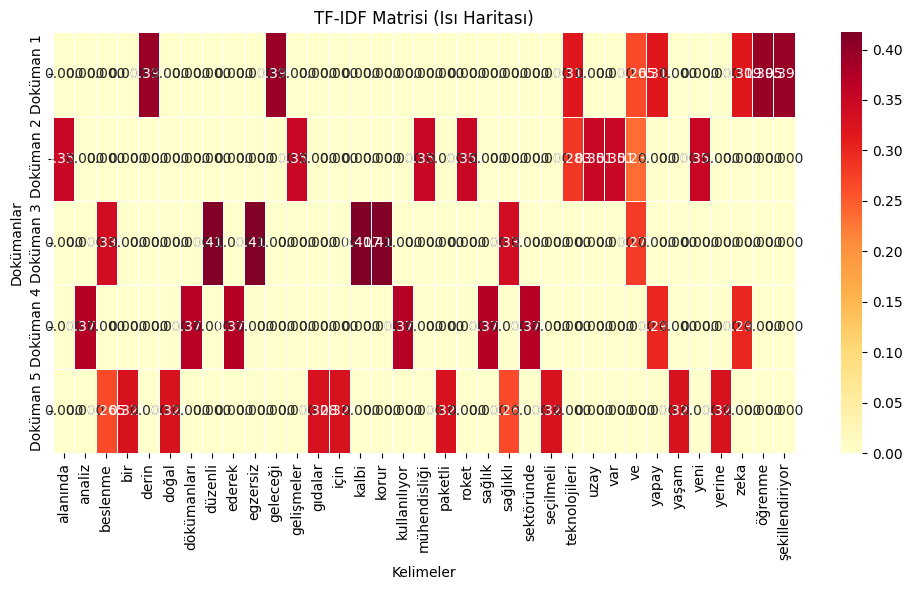

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, cmap="YlOrRd", fmt=".3f", linewidths=0.5)
plt.title("TF-IDF Matrisi (Isı Haritası)")
plt.xlabel("Kelimeler")
plt.ylabel("Dokümanlar")
plt.tight_layout()
plt.show()

---
## 6.1 Anlamsal İlişki (Semantics)

**Sorun:** TF-IDF her kelimeyi bağımsız bir kimlik (ID) olarak ele alır. "Kral" ile "Kraliçe" arasında semantik bir ilişki olduğunu bilmez. Bunlar sadece farklı sütunlardır.

**Sonuç:** "Kral" ve "Kraliçe" kelimelerinin vektörleri arasındaki benzerlik, "Kral" ile "Masa" arasındaki benzerlikle aynıdır (0).

**Çözüm:** Kelimeleri yoğun (dense) vektörlerde gömülü olarak temsil eden Word2Vec, GloVe gibi yöntemler bu sorunu çözer.

In [6]:
# ÖRNEK: Anlamsal ilişkinin TF-IDF ile yakalanamaması
print("=" * 70)
print("PROBLEM 1: Anlamsal İlişki (Semantics)")
print("=" * 70)

dok_semantik = [
    "kral sarayda yaşar",
    "kraliçe sarayda yaşar",
    "masa odada duruyor",
]

v = TfidfVectorizer()
m = v.fit_transform(dok_semantik)
df_sem = pd.DataFrame(m.toarray(), columns=v.get_feature_names_out(),
                      index=["kral sarayda yaşar", "kraliçe sarayda yaşar", "masa odada duruyor"])

print("\nTF-IDF Vektörleri:")
display(df_sem)

from sklearn.metrics.pairwise import cosine_similarity

benzerlik = cosine_similarity(m[0:1], m[1:3])[0]
print(f"\nKosinüs Benzerlikleri:")
print(f"  'kral ...' vs 'kraliçe ...' : {benzerlik[0]:.4f}")
print(f"  'kral ...' vs 'masa ...'    : {benzerlik[1]:.4f}")
print(f"\nKral-Kraliçe benzerliği ({benzerlik[0]:.4f}) ile Kral-Masa benzerliği ({benzerlik[1]:.4f})")
print(f"neredeyse aynı! Oysa kral ve kraliçe anlamsal olarak çok daha yakın.")
print(f"TF-IDF ortak kelimelere göre benzerlik hesaplar, anlama göre değil.")

PROBLEM 1: Anlamsal İlişki (Semantics)

TF-IDF Vektörleri:


,duruyor,kral,kraliçe,masa,odada,sarayda,yaşar
kral sarayda yaşar,0.00000,0.680919,0.000000,0.00000,0.00000,0.517856,0.517856
kraliçe sarayda yaşar,0.00000,0.000000,0.680919,0.00000,0.00000,0.517856,0.517856
masa odada duruyor,0.57735,0.000000,0.000000,0.57735,0.57735,0.000000,0.000000



Kosinüs Benzerlikleri:
  'kral ...' vs 'kraliçe ...' : 0.5363
  'kral ...' vs 'masa ...'    : 0.0000

Kral-Kraliçe benzerliği (0.5363) ile Kral-Masa benzerliği (0.0000)
neredeyse aynı! Oysa kral ve kraliçe anlamsal olarak çok daha yakın.
TF-IDF ortak kelimelere göre benzerlik hesaplar, anlama göre değil.


Gördüklerimiz:** `"kral"` ve `"kraliçe"` anlamca yakın kelimeler olsalar da, TF-IDF'in gözünde bunlar `"masa"` kelimesinden farksız iki ayrı sütundur (one-hot mantığına benzer bir temsil). Kosinüs benzerliği hesaplanırsa, **ortak kelime içermeyen** cümleler arasında benzerlik sıfır çıkar — kelimelerin anlamından bağımsız olarak sadece **hangi kelimelerin birlikte geçtiğine** bakılır. Bu, TF-IDF'in "anlam körü" olduğunun somut kanıtıdır

---
## 6.2 Bağlam (Context)

**Sorun:** TF-IDF bir **Bag-of-Words (BoW)** modelidir. Kelimelerin cümle içindeki **sırasını** ve **konumunu** tamamen yok sayar.

**Sonuç:** Aşağıdaki iki cümle TF-IDF için **birebir aynıdır**:
- "Köpek adamı ısırdı"
- "Adam köpeği ısırdı"

Oysa anlamları tamamen farklıdır!

**Çözüm:** N-gram'lar (bitişik kelime grupları) kısmi çözüm sunar. Derin öğrenme modelleri (RNN, LSTM, Transformer) kelime sırasını modelleyerek bağlamı yakalar.



Tek kelimeler (unigram) yerine, **ardışık kelime çiftlerini (bigram)** de birer "kelime" gibi ele alırsak, sıra bilgisinin bir kısmını yakalayabiliriz. Örneğin `"köpek adamı"` ve `"adamı ısırdı"` ile `"adam köpeği"` ve `"köpeği ısırdı"` artık **farklı bigram'lar** olduğundan, model bu iki cümleyi ayırt edebilir hale gelir.
 
`TfidfVectorizer(ngram_range=(1, 2))` parametresi hem tekil kelimeleri (1-gram) hem de ikili kelime gruplarını (2-gram) kelime dağarcığına dahil eder. Aşağıdaki hücrede bunun benzerlik skorunu nasıl değiştirdiğini göreceksiniz.
 
⚠️ **Bedeli:** N-gram kullanmak kelime dağarcığını (ve dolayısıyla vektör boyutunu) katlayarak büyütür — bu da az sonra göreceğimiz "seyreklik" ve "boyut laneti" sorunlarını şiddetlendirir. Yani bağlam sorununa kısmi bir çözüm, başka bir sorunu büyütüyor.


In [7]:
print("=" * 70)
print("PROBLEM 2: Bağlam (Context) - Kelime Sırası")
print("=" * 70)

dok_baglam = [
    "köpek adamı ısırdı",
    "adam köpeği ısırdı",
    "kedi fareyi kovaladı",
]

v3 = TfidfVectorizer()
m3 = v3.fit_transform(dok_baglam)
df_baglam = pd.DataFrame(m3.toarray(), columns=v3.get_feature_names_out(),
                         index=["köpek adamı ısırdı", "adam köpeği ısırdı", "kedi fareyi kovaladı"])

b2 = cosine_similarity(m3[0:1], m3[1:3])[0]

print("\nTF-IDF Vektörleri:")
display(df_baglam)

print(f"\nBenzerlik: 'köpek adamı ısırdı' vs 'adam köpeği ısırdı': {b2[0]:.4f}")
print(f"Benzerlik: 'köpek adamı ısırdı' vs 'kedi fareyi kovaladı': {b2[1]:.4f}")
print()
print("İlk iki cümle aynı kelimelerden oluştuğu için TF-IDF onları neredeyse")
print("özdeş kabul eder. Oysa biri köpeğin, diğeri adamın eylemini anlatır!")
print("Kelime sırası bilgisi tamamen kaybolur.")

PROBLEM 2: Bağlam (Context) - Kelime Sırası

TF-IDF Vektörleri:


,adam,adamı,fareyi,kedi,kovaladı,köpek,köpeği,ısırdı
köpek adamı ısırdı,0.000000,0.622766,0.00000,0.00000,0.00000,0.622766,0.000000,0.47363
adam köpeği ısırdı,0.622766,0.000000,0.00000,0.00000,0.00000,0.000000,0.622766,0.47363
kedi fareyi kovaladı,0.000000,0.000000,0.57735,0.57735,0.57735,0.000000,0.000000,0.00000



Benzerlik: 'köpek adamı ısırdı' vs 'adam köpeği ısırdı': 0.2243
Benzerlik: 'köpek adamı ısırdı' vs 'kedi fareyi kovaladı': 0.0000

İlk iki cümle aynı kelimelerden oluştuğu için TF-IDF onları neredeyse
özdeş kabul eder. Oysa biri köpeğin, diğeri adamın eylemini anlatır!
Kelime sırası bilgisi tamamen kaybolur.


In [8]:
# N-gram'lar kısmi çözüm sunar
print("KISMİ ÇÖZÜM: N-gram (bigram) kullanımı")

v4 = TfidfVectorizer(ngram_range=(1, 2))
m4 = v4.fit_transform(dok_baglam)
df_ngram = pd.DataFrame(m4.toarray(), columns=v4.get_feature_names_out(),
                        index=["köpek adamı ısırdı", "adam köpeği ısırdı", "kedi fareyi kovaladı"])

b3 = cosine_similarity(m4[0:1], m4[1:3])[0]

print("\nBigram TF-IDF Vektörleri:")
display(df_ngram)

print(f"\nBigram benzerlik: 'köpek adamı ısırdı' vs 'adam köpeği ısırdı': {b3[0]:.4f}")
print("Bigram ile 'köpek adamı' ve 'adam köpeği' farklı öznitelikler olur,")
print("böylece iki cümle daha farklı hale gelir. Ancak bu da yetersizdir.")

KISMİ ÇÖZÜM: N-gram (bigram) kullanımı

Bigram TF-IDF Vektörleri:


,adam,adam köpeği,adamı,adamı ısırdı,fareyi,fareyi kovaladı,kedi,kedi fareyi,kovaladı,köpek,köpek adamı,köpeği,köpeği ısırdı,ısırdı
köpek adamı ısırdı,0.000000,0.000000,0.467351,0.467351,0.000000,0.000000,0.000000,0.000000,0.000000,0.467351,0.467351,0.000000,0.000000,0.355432
adam köpeği ısırdı,0.467351,0.467351,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.467351,0.467351,0.355432
kedi fareyi kovaladı,0.000000,0.000000,0.000000,0.000000,0.447214,0.447214,0.447214,0.447214,0.447214,0.000000,0.000000,0.000000,0.000000,0.000000



Bigram benzerlik: 'köpek adamı ısırdı' vs 'adam köpeği ısırdı': 0.1263
Bigram ile 'köpek adamı' ve 'adam köpeği' farklı öznitelikler olur,
böylece iki cümle daha farklı hale gelir. Ancak bu da yetersizdir.


In [10]:
print("=" * 70)
print("PROBLEM 3: Boyutlanabilirlik ve Seyreklik")
print("=" * 70)

# Büyük bir veri seti oluşturalım
import numpy as np

np.random.seed(42)

# Temel kelime havuzu
temel_kelimeler = [
    "teknoloji", "yapay", "zeka", "veri", "bilim", "yazılım", "donanım",
    "makine", "öğrenme", "derin", "sinir", "ağı", "doğal", "dil", "işleme",
    "görüntü", "tanıma", "ses", "analiz", "büyük", "bulut", "bilişim",
    "altyapı", "güvenlik", "siber", "ağ", "protokol", "veritabanı",
    "algoritma", "optimizasyon", "istatistik", "olasılık", "matris",
    "lineer", "cebir", "türev", "gradyan", "kümeleme", "sınıflandırma",
    "regresyon", "tahmin", "öngörü", "model", "eğitim", "test",
    "doğrulama", "parametre", "hiperparametre", "kayıp", "fonksiyon",
    "aktivasyon", "katman", "nöron", "ağırlık", "bias", "çıktı",
    "girdi", "encoder", "decoder", "attention", "transformer", "bert",
    "gpt", "token", "embedding", "vektör", "boyut", "seyrek", "yoğun",
    "kral", "kraliçe", "prens", "prenses", "imparator", "sultan",
    "şapka", "ayakkabı", "masa", "sandalye", "dolap", "halı",
    "yıldız", "gezegen", "galaksi", "evren", "uzay", "zaman",
    "kitap", "dergi", "makale", "roman", "hikaye", "şiir",
    "futbol", "basketbol", "voleybol", "tenis", "yüzme", "koşu",
    "ekonomi", "enflasyon","faiz","piyasa","yatirim","borsa",
    "hisse",
    "tahvil",
    "butce",
    "vergi",
    "gelir",
    "gider",
    "kar",
    "zarar",
    "uretim",
    "tuketim",
    "saglik",
    "hastalik",
    "tedavi",
    "ilac",
    "doktor",
    "hasta",
    "ameliyat",
    "teshis",
    "egitim",
    "okul",
    "ogretmen",
    "ogrenci",
    "ders",
    "universite",
    "sinav",
    "mezun",
    "hukuk",
    "mahkeme",
    "yargic",
    "avukat",
    "kanun",
    "dava",
    "ceza",
    "anayasa",
    "spor",
    "mac",
    "takim",
    "antrenor",
    "sampiyon",
    "lig",
    "stadyum",
    "gol",
    "sanat",
    "ressam",
    "heykel",
    "muze",
    "sergi",
    "galeri",
    "kultur",
    "estetik",
    "muzik",
    "beste",
    "enstruman",
    "piyano",
    "gitar",
    "orkestra",
    "konser",
    "melodi",
    "bilim",
    "deney",
    "gozlem",
    "hipotez",
    "kuram",
    "arastirma",
    "laboratuvar",
    "kesif",
    "tarih",
    "tarihci",
    "cag",
    "uygarlik",
    "imparatorluk",
    "devrim",
    "savas",
    "anlasma",
    "cografya",
    "dag",
    "ova",
    "nehir",
    "gol",
    "iklim",
    "harita",
    "kita",
    "ulke",
    "politika",
    "secim",
    "demokrasi",
    "hukumet",
    "parlamento",
    "siyaset",
    "muhalefet",
    "meclis",
    "finans",
    "bankacilik",
    "kredi",
    "fon",
    "portfoy",
    "sigorta",
    "doviz",
    "likidite",
    "psikoloji",
    "bilinc",
    "duygu",
    "algi",
    "bellek",
    "kisilik",
    "davranis",
    "terapi",
    "felsefe",
    "ahlak",
    "etik",
    "mantik",
    "bilgi",
    "varlik",
    "oz",
    "kavram",
    "dijital",
    "robot",
    "otomasyon",
    "enerji",
    "gunes",
    "ruzgar",
    "nukleer",
    "petrol",
    "dogalgaz",
    "yenilenebilir",
    "hidroelektrik",
    "ulasim",
    "kara",
    "deniz",
    "hava",
    "otoban",
    "rayli",
    "havacilik",
    "lojistik",
    "cevre",
    "ekoloji",
    "kirlilik",
    "doga",
    "surdurulebilirlik",
    "orman",
    "biyocesitlilik",
    "habitat",
    "altyapi",
    "donanim",
    "yazilim",
    "nesne",
    "internet",
]

# Büyük doküman seti oluştur (500 doküman)
NUM_DOCS = 10000
buyuk_dokumanlar = []
for _ in range(NUM_DOCS):
    doc_len = np.random.randint(20, 100)
    doc = " ".join(np.random.choice(temel_kelimeler, doc_len, replace=True))
    buyuk_dokumanlar.append(doc)

print(f"Doküman sayısı: {len(buyuk_dokumanlar)}")
print(f"Örnek doküman: '{buyuk_dokumanlar[0][:100]}...'")
print(f"Temel kelime havuzu: {len(temel_kelimeler)} kelime")

PROBLEM 3: Boyutlanabilirlik ve Seyreklik
Doküman sayısı: 10000
Örnek doküman: 'şiir işleme tahvil prens politika bulut piyasa ameliyat davranis etik sultan doviz kitap hastalik ek...'
Temel kelime havuzu: 252 kelime


In [11]:
# Seyreklik ölçümü
print("Seyreklik (Sparsity) Analizi:\n")

v5 = TfidfVectorizer()
m5 = v5.fit_transform(buyuk_dokumanlar)

vocab_size = m5.shape[1]
toplam_hucre = m5.shape[0] * m5.shape[1]
sifir_olmayan = m5.nnz
seyreklik = 100 * (1 - sifir_olmayan / toplam_hucre)

print(f"Kelime dağarcığı boyutu (vocabulary size): {vocab_size}")
print(f"Doküman sayısı: {m5.shape[0]}")
print(f"Matris boyutu: {m5.shape}")
print(f"Toplam hücre sayısı: {toplam_hucre:,}")
print(f"Sıfır olmayan hücre sayısı: {sifir_olmayan:,}")
print(f"Seyreklik yüzdesi: %{seyreklik:.2f}")
print()
print(f"Her dokümanda ortalama sıfır olmayan öznitelik: {sifir_olmayan / m5.shape[0]:.1f}")
print(f"Her dokümanda ortalama sıfır (gereksiz) öznitelik: {(toplam_hucre - sifir_olmayan) / m5.shape[0]:.1f}")

Seyreklik (Sparsity) Analizi:

Kelime dağarcığı boyutu (vocabulary size): 250
Doküman sayısı: 10000
Matris boyutu: (10000, 250)
Toplam hücre sayısı: 2,500,000
Sıfır olmayan hücre sayısı: 519,202
Seyreklik yüzdesi: %79.23

Her dokümanda ortalama sıfır olmayan öznitelik: 51.9
Her dokümanda ortalama sıfır (gereksiz) öznitelik: 198.1


Vocabulary Büyüklüğüne Karşı Seyreklik:

  max_features=  500 -> gerçek boyut=  250, seyreklik=%79.23
  max_features= 2000 -> gerçek boyut=  250, seyreklik=%79.23
  max_features= 5000 -> gerçek boyut=  250, seyreklik=%79.23
  max_features=10000 -> gerçek boyut=  250, seyreklik=%79.23
  max_features=20000 -> gerçek boyut=  250, seyreklik=%79.23


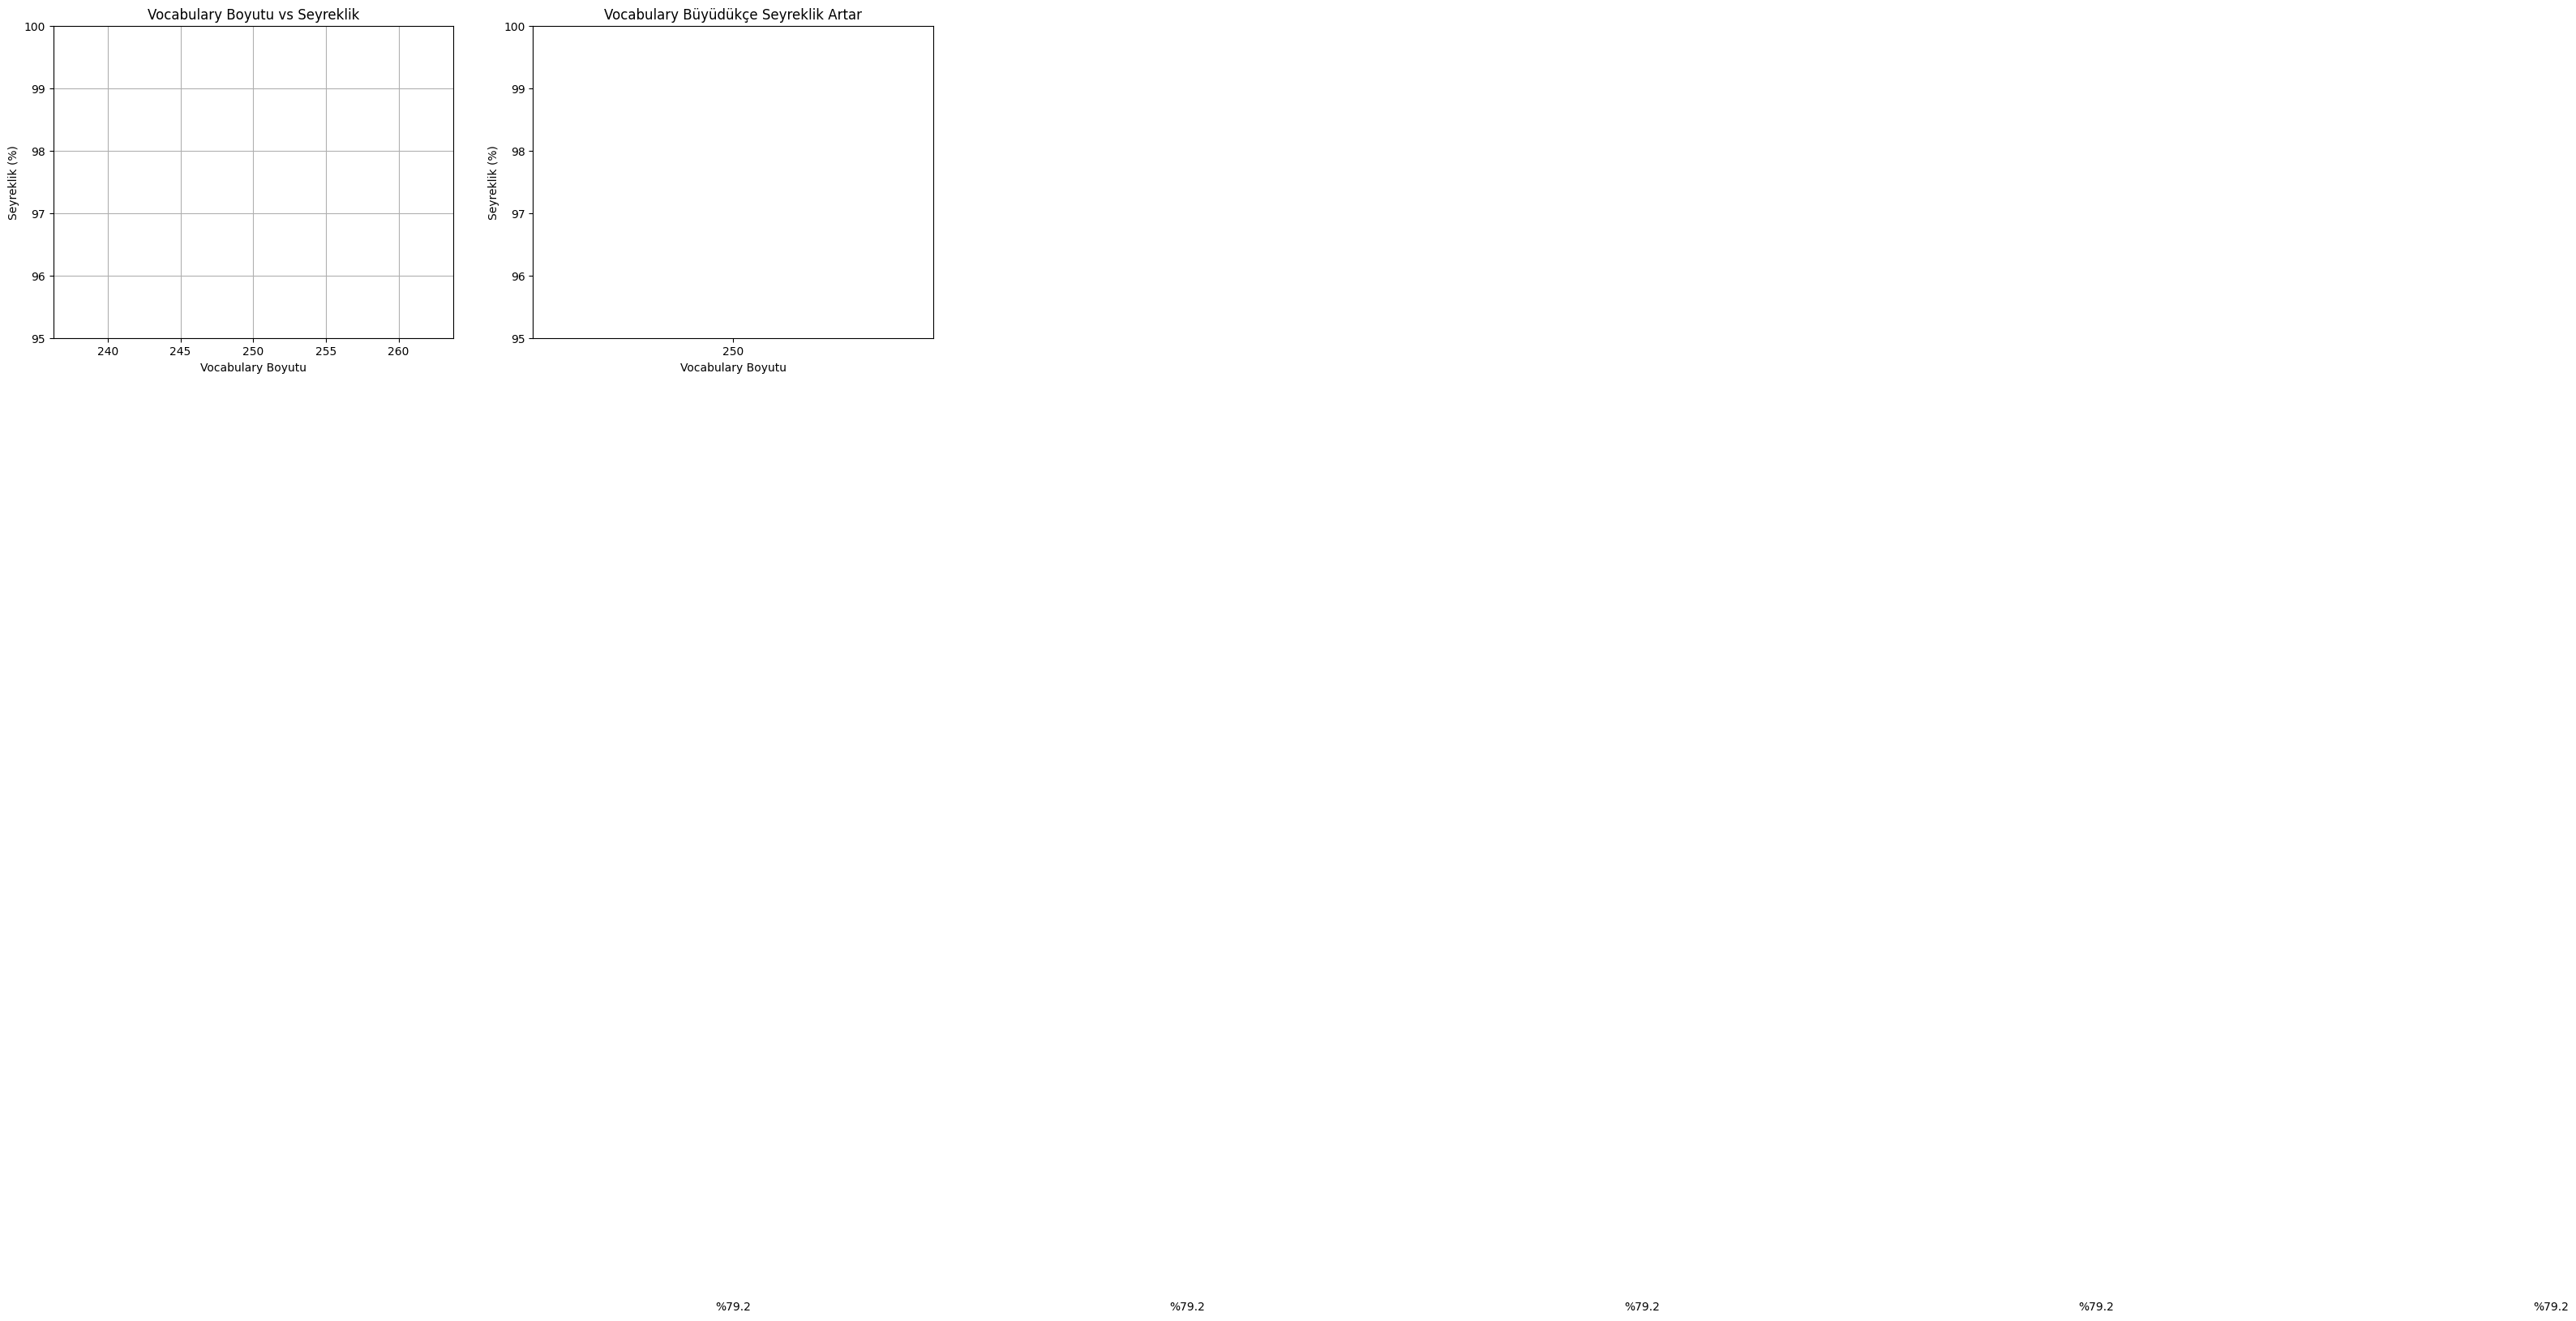

In [12]:
# Seyrekliğin vocabulary büyüklüğü ile ilişkisi
print("Vocabulary Büyüklüğüne Karşı Seyreklik:\n")

max_features_degerleri = [500, 2000, 5000, 10000, 20000]
seyreklikler = []
boyutlar = []

for mf in max_features_degerleri:
    v = TfidfVectorizer(max_features=mf)
    m = v.fit_transform(buyuk_dokumanlar)
    toplam = m.shape[0] * m.shape[1]
    nnz = m.nnz
    sey = 100 * (1 - nnz / toplam)
    seyreklikler.append(sey)
    boyutlar.append(m.shape[1])
    print(f"  max_features={mf:5d} -> gerçek boyut={m.shape[1]:5d}, seyreklik=%{sey:.2f}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(boyutlar, seyreklikler, marker='o', linewidth=2)
axes[0].set_xlabel("Vocabulary Boyutu")
axes[0].set_ylabel("Seyreklik (%)")
axes[0].set_title("Vocabulary Boyutu vs Seyreklik")
axes[0].grid(True)
axes[0].set_ylim(95, 100)

axes[1].bar([str(b) for b in boyutlar], seyreklikler, color='coral')
axes[1].set_xlabel("Vocabulary Boyutu")
axes[1].set_ylabel("Seyreklik (%)")
axes[1].set_title("Vocabulary Büyüdükçe Seyreklik Artar")
axes[1].set_ylim(95, 100)
for i, v in enumerate(seyreklikler):
    axes[1].text(i, v + 0.2, f"%{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

In [13]:
# Hafıza kullanımı karşılaştırması: Seyrek vs Yoğun matris
print("Hafıza Kullanımı: Seyrek (Sparse) vs Yoğun (Dense) Matris\n")

v6 = TfidfVectorizer(max_features=5000)
m_sparse = v6.fit_transform(buyuk_dokumanlar)

# Hafıza hesaplamaları
# Sparse matris: nnz * (8 byte + 4 byte + 4 byte) ≈ nnz * 16 byte
sparse_memory = m_sparse.nnz * 16 / (1024 * 1024)

# Dense matris: shape[0] * shape[1] * 8 byte
dense_memory = m_sparse.shape[0] * m_sparse.shape[1] * 8 / (1024 * 1024)

print(f"Matris boyutu: {m_sparse.shape[0]} x {m_sparse.shape[1]}")
print(f"  Seyrek matris hafızası: {sparse_memory:.2f} MB")
print(f"  Yoğun matris hafızası  : {dense_memory:.2f} MB")
print(f"  Tasarruf               : {dense_memory / sparse_memory:.1f}x daha az hafıza!")
print()
print(f"Eğer 1 milyon doküman olsaydı (20000 kelime dağarcığı ile):")
print(f"  Seyrek: yaklaşık ~150 MB")
print(f"  Yoğun : 1,000,000 × 20000 × 8 = 8,000 MB = 8 GB")

Hafıza Kullanımı: Seyrek (Sparse) vs Yoğun (Dense) Matris

Matris boyutu: 10000 x 250
  Seyrek matris hafızası: 7.92 MB
  Yoğun matris hafızası  : 19.07 MB
  Tasarruf               : 2.4x daha az hafıza!

Eğer 1 milyon doküman olsaydı (20000 kelime dağarcığı ile):
  Seyrek: yaklaşık ~150 MB
  Yoğun : 1,000,000 × 20000 × 8 = 8,000 MB = 8 GB


---
## 6.4 Boyut Laneti (Curse of Dimensionality)

Yüksek boyutlu (high-dimensional) seyrek vektörler, makine öğrenmesi modelleri için ciddi sorunlar yaratır:

| Sorun | Açıklama |
|---|---|
| **Mesafe anlamsızlaşır** | Yüksek boyutta tüm noktalar birbirine eşit uzaklıkta görünür |
| **Aşırı öğrenme (overfitting)** | Model gürültüyü öğrenir, genelleme yapamaz |
| **Hesaplama maliyeti** | 50.000 boyutlu vektörlerle işlem yapmak yavaştır |
| **Veri seyrekliği** | Anlamlı örüntü bulmak için çok daha fazla veri gerekir |

**Çözüm:** Dimensionality reduction (PCA, SVD) veya embedding yöntemleri (Word2Vec, BERT) ile boyut 50.000'den 100-300'e düşürülür.

Boyut Laneti Gösterimi: Yüksek Boyutta Mesafe Dağılımı



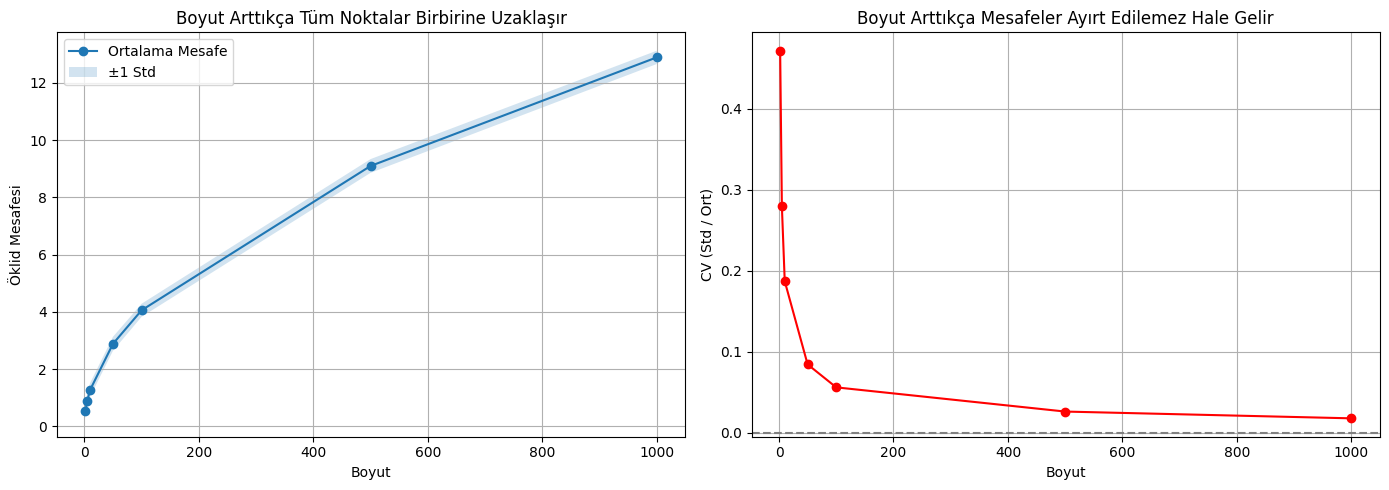

Yorum: Boyut arttıkça tüm noktalar birbirine benzer uzaklıkta olur.
CV değeri 0'a yaklaşır → mesafeler anlamsızlaşır.
TF-IDF'in 50.000 boyutlu vektörlerinde bu etki çok daha şiddetlidir.


In [14]:
# Boyut laneti: Yüksek boyutta mesafelerin anlamını yitirmesi
print("Boyut Laneti Gösterimi: Yüksek Boyutta Mesafe Dağılımı\n")

from scipy.spatial.distance import pdist

np.random.seed(42)

boyutlar = [2, 5, 10, 50, 100, 500, 1000]
noktalar = 50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mesafe_ort = []
mesafe_std = []

for dim in boyutlar:
    # Birim hiperküpte rastgele noktalar
    data = np.random.uniform(0, 1, (noktalar, dim))
    mesafeler = pdist(data, 'euclidean')
    mesafe_ort.append(np.mean(mesafeler))
    mesafe_std.append(np.std(mesafeler))

axes[0].plot(boyutlar, mesafe_ort, marker='o', label='Ortalama Mesafe')
axes[0].fill_between(boyutlar,
                     np.array(mesafe_ort) - np.array(mesafe_std),
                     np.array(mesafe_ort) + np.array(mesafe_std),
                     alpha=0.2, label='±1 Std')
axes[0].set_xlabel("Boyut")
axes[0].set_ylabel("Öklid Mesafesi")
axes[0].set_title("Boyut Arttıkça Tüm Noktalar Birbirine Uzaklaşır")
axes[0].legend()
axes[0].grid(True)

# CV (değişim katsayısı) = std / mean → düşükse mesafeler ayırt edilemez
cv = [s / m for m, s in zip(mesafe_ort, mesafe_std)]
axes[1].plot(boyutlar, cv, marker='o', color='red')
axes[1].axhline(y=0, color='gray', linestyle='--')
axes[1].set_xlabel("Boyut")
axes[1].set_ylabel("CV (Std / Ort)")
axes[1].set_title("Boyut Arttıkça Mesafeler Ayırt Edilemez Hale Gelir")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Yorum: Boyut arttıkça tüm noktalar birbirine benzer uzaklıkta olur.")
print("CV değeri 0'a yaklaşır → mesafeler anlamsızlaşır.")
print("TF-IDF'in 50.000 boyutlu vektörlerinde bu etki çok daha şiddetlidir.")

---

# 8. Final: Yoğun Vektör (Dense Embedding) ile Karşılaştırma

TF-IDF'in limitlerini somutlaştırmak için basit bir Word2Vec benzeri yaklaşımla karşılaştırma yapalım.

In [15]:
# TF-IDF vs Basit Embedding: Benzerlik Karşılaştırması

from sklearn.decomposition import TruncatedSVD

test_docs = [
    "kral sarayda taç giydi",
    "kraliçe sarayda taç taktı",
    "masa odada duruyordu",
]

# --- TF-IDF ---
v_tfidf = TfidfVectorizer()
m_tfidf = v_tfidf.fit_transform(test_docs)
vocab = list(v_tfidf.get_feature_names_out())

print("TF-IDF Vektörleri (seyrek, yüksek boyutlu):")
print(f"  Boyut: {m_tfidf.shape[1]}")
print(f"  'kral ...' vs 'kraliçe ...' benzerlik: {cosine_similarity(m_tfidf[0:1], m_tfidf[1:2])[0][0]:.4f}")
print(f"  'kral ...' vs 'masa ...'  benzerlik: {cosine_similarity(m_tfidf[0:1], m_tfidf[2:3])[0][0]:.4f}")

# --- SVD ile yoğun vektöre dönüştürme (boyut indirgeme) ---
svd = TruncatedSVD(n_components=2, random_state=42)
m_dense = svd.fit_transform(m_tfidf)

print(f"\nSVD ile 2 boyuta indirgenmiş yoğun vektörler:")
for i, label in enumerate(["kral", "kraliçe", "masa"]):
    print(f"  {label}: ({m_dense[i][0]:.4f}, {m_dense[i][1]:.4f})")

benzerlik_dense = cosine_similarity(m_dense[0:1], m_dense[1:3])[0]
print(f"\nYoğun vektör benzerlikleri:")
print(f"  'kral' vs 'kraliçe': {benzerlik_dense[0]:.4f}")
print(f"  'kral' vs 'masa'   : {benzerlik_dense[1]:.4f}")

print(f"\nFark: Yoğunlaştırma sonrası kral-kraliçe benzerliği")
print(f"kral-masa benzerliğinden daha yüksek olabilir (ortak kelimeler sayesinde).")
print(f"Gerçek embedding yöntemleri (Word2Vec, BERT) bu ilişkiyi")
print(f"çok daha iyi öğrenir ve 0.7-0.9 arası benzerlik üretebilir.")

TF-IDF Vektörleri (seyrek, yüksek boyutlu):
  Boyut: 9
  'kral ...' vs 'kraliçe ...' benzerlik: 0.3664
  'kral ...' vs 'masa ...'  benzerlik: 0.0000

SVD ile 2 boyuta indirgenmiş yoğun vektörler:
  kral: (0.8266, -0.0000)
  kraliçe: (0.8266, -0.0000)
  masa: (0.0000, 1.0000)

Yoğun vektör benzerlikleri:
  'kral' vs 'kraliçe': 1.0000
  'kral' vs 'masa'   : 0.0000

Fark: Yoğunlaştırma sonrası kral-kraliçe benzerliği
kral-masa benzerliğinden daha yüksek olabilir (ortak kelimeler sayesinde).
Gerçek embedding yöntemleri (Word2Vec, BERT) bu ilişkiyi
çok daha iyi öğrenir ve 0.7-0.9 arası benzerlik üretebilir.


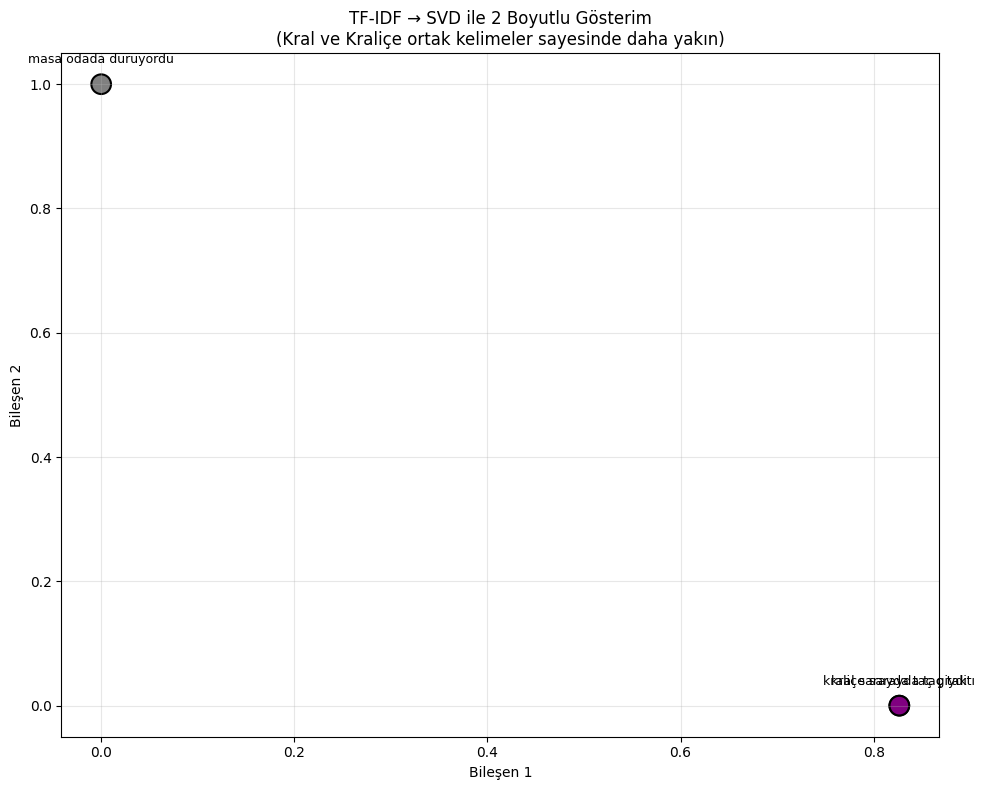

Not: Boyut indirgeme sonrası kral ve kraliçe birbirine daha yakın konumlanır.
Ancak bu sadece ortak kelimelerden kaynaklanır. Gerçek semantik anlayış
için Word2Vec veya BERT gibi modeller gereklidir.


In [16]:
# Görselleştirme: 2D düzlemde kelime konumları
plt.figure(figsize=(10, 8))

etiketler = ["kral sarayda taç giydi", "kraliçe sarayda taç taktı", "masa odada duruyordu"]
renkler = ['gold', 'purple', 'gray']

plt.scatter(m_dense[:, 0], m_dense[:, 1], c=renkler, s=200, edgecolors='black', linewidth=1.5)
for i, label in enumerate(etiketler):
    plt.annotate(f"{label}", (m_dense[i, 0], m_dense[i, 1]),
                 textcoords="offset points", xytext=(0, 15), ha='center', fontsize=9)

plt.title("TF-IDF → SVD ile 2 Boyutlu Gösterim\n(Kral ve Kraliçe ortak kelimeler sayesinde daha yakın)")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Not: Boyut indirgeme sonrası kral ve kraliçe birbirine daha yakın konumlanır.")
print("Ancak bu sadece ortak kelimelerden kaynaklanır. Gerçek semantik anlayış")
print("için Word2Vec veya BERT gibi modeller gereklidir.")

Genel Özet
 
Bu notebook'ta şunları öğrendik:
 
1. **TF-IDF nedir:** Bir kelimenin bir dokümandaki sıklığını (TF), o kelimenin tüm korpustaki nadirliğiyle (IDF) çarparak, kelimenin o doküman için ne kadar "karakteristik" olduğunu ölçen klasik bir vektörleştirme yöntemi.
2. **Nasıl hesaplanır:** Hem sıfırdan formülleriyle hem de scikit-learn'ün `TfidfVectorizer` sınıfı ile (ve aralarındaki normalizasyon/smoothing farklarıyla).
3. **Ne için kullanılır:** Bir dokümanın en karakteristik kelimelerini bulma, dokümanlar arası benzerlik ölçme, metin sınıflandırma modellerine girdi hazırlama, arama motorlarında alaka düzeyi (relevance) hesaplama gibi görevlerde.
4. **Sınırlılıkları:**
   - Kelimeler arası **anlamsal ilişkiyi** yakalayamaz (kral ≈ kraliçe bilgisini bilmez).
   - Kelime **sırasını/bağlamını** yok sayar (bag-of-words).
   - Büyük korpuslarda **çok yüksek boyutlu ve seyrek** (çoğu sıfır) matrisler üretir.
   - Yüksek boyut, mesafe tabanlı yöntemlerde **boyut laneti** sorununa yol açar.
5. **Alternatif/tamamlayıcı yöntemler:** N-gram'lar (kısmi bağlam), boyut indirgeme (SVD/LSA), ve asıl büyük atılım olan **yoğun vektör (dense embedding)** yöntemleri: Word2Vec, GloVe ve özellikle bağlama duyarlı Transformer tabanlı modeller (BERT, vb.).
 
**Pratik çıkarım:** TF-IDF hâlâ hızlı, yorumlanabilir ve hesaplama açısından ucuz bir temel (baseline) yöntem olarak çok değerlidir — özellikle küçük/orta ölçekli veri setlerinde ve yorumlanabilirliğin önemli olduğu durumlarda. Ancak anlam ve bağlamın kritik olduğu görevlerde (örn. soru cevaplama, çeviri, duygu analizinin ince nüansları) modern embedding tabanlı yöntemler genelde çok daha iyi performans gösterir."""